In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split,KFold,cross_val_score,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,r2_score

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [5]:
df=pd.read_csv("DataCoSupplyChainDataset.csv")
df_original=df.copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [7]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


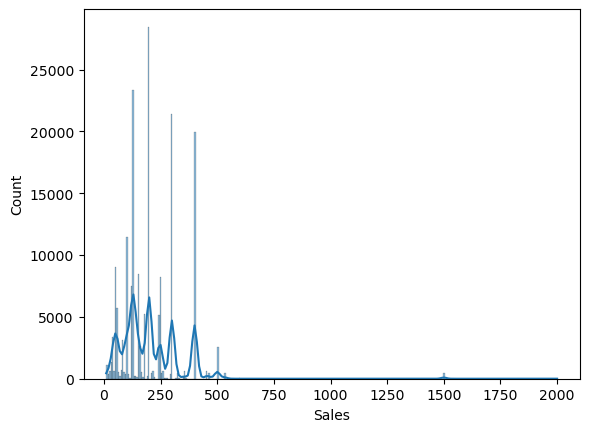

In [8]:
#sales distributions
sns.histplot(df['Sales'],kde=True)
plt.show()

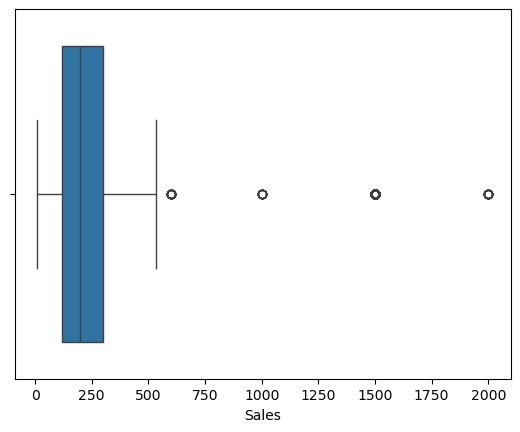

In [9]:
#boxplot(before outlier removal)
sns.boxplot(x=df_original['Sales'])
plt.show()

In [10]:
print("Before cleaning:",df.shape)

Before cleaning: (180519, 53)


In [11]:
#data cleaning 
df = df.fillna(method='ffill')

<ipython-input-11-ae92ea3389ae>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [12]:
Q1=df['Sales'].quantile(0.25)
Q3=df['Sales'].quantile(0.75)
IQR=Q3-Q1
df=df[(df['Sales']>= Q1-3*IQR) & (df['Sales']<= Q3+3*IQR)]
print("after cleaning:", df.shape)

after cleaning: (180052, 53)


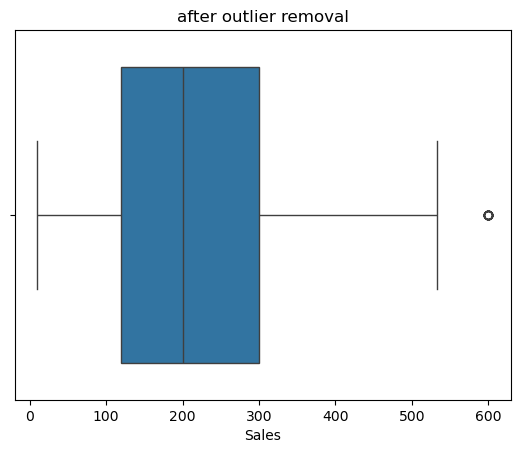

In [13]:
#boxplot (after outlier removal)
sns.boxplot(x=df['Sales'])
plt.title("after outlier removal")
plt.show()

In [14]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [15]:
#feature engineering
df['Order date']=pd.to_datetime(df['order date (DateOrders)'])
df['Shipping date']=pd.to_datetime(df['shipping date (DateOrders)'])

df['Total_price']=df['Order Item Quantity']*df['Order Item Product Price']
df['Delivery_Delay']=df['Days for shipping (real)']-df['Days for shipment (scheduled)']
df['Discount_Impact']=df['Order Item Discount']*df['Order Item Product Price']

df['Shipping_Duration']=(df['Shipping date']-df['Order date']).dt.days

df['Order_Month']=df['Order date'].dt.month
df['Order_Weekday']=df['Order date'].dt.weekday

In [16]:
df=pd.get_dummies(df,columns=['Shipping Mode'],drop_first=True)

In [17]:
df=df.drop(columns=['Order Id', 'Customer Id', 'Product Card Id','order date (DateOrders)', 'shipping date (DateOrders)'],errors='ignore')

In [18]:
features =['Order Item Product Price',
           'Order Item Discount',
           'Delivery_Delay',
           'Shipping_Duration',
           'Order_Month',
           'Order_Weekday']

X = df[features]
y = df['Sales']

In [19]:
corr = X.corrwith(y).sort_values(ascending=False)
print(corr.head(10))

Order Item Product Price    0.719560
Order Item Discount         0.580256
Order_Month                 0.030742
Shipping_Duration           0.000709
Delivery_Delay             -0.001997
Order_Weekday              -0.003927
dtype: float64


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [21]:
lr=LinearRegression()
lr.fit(X_train, y_train)
lr_pred=lr.predict(X_test)

print("R2 score(Linear Regression):", r2_score(y_test, lr_pred))

R2 score(Linear Regression): 0.6135565843839794


In [22]:
rf = RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_split=10,min_samples_leaf=5,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("R2 score(Random Forest):", r2_score(y_test, rf_pred))

R2 score(Random Forest): 0.8181700329025028


In [23]:
xgbr=XGBRegressor( n_estimators=200,max_depth=5,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgbr.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(xgbr,X,y,cv=kfold)
print("CV Score:",cv_scores.mean())

CV Score: 0.8264620609723495


In [25]:
pipeline =Pipeline([('scaler',StandardScaler()),
                     ('model',XGBRegressor(random_state=42))])
params ={'model__n_estimators':[100, 200],
          'model__max_depth':[3, 5, 7],
          'model__learning_rate':[0.01, 0.1, 0.2]}

random_search =RandomizedSearchCV(pipeline,param_distributions=params,n_iter=5,cv=3,random_state=42)
random_search.fit(X_train,y_train)

best_model =random_search.best_estimator_

In [26]:
y_pred=best_model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,y_pred))
print("R2:",r2_score(y_test,y_pred))

MAE: 28.566633932383453
R2: 0.8233185743849993


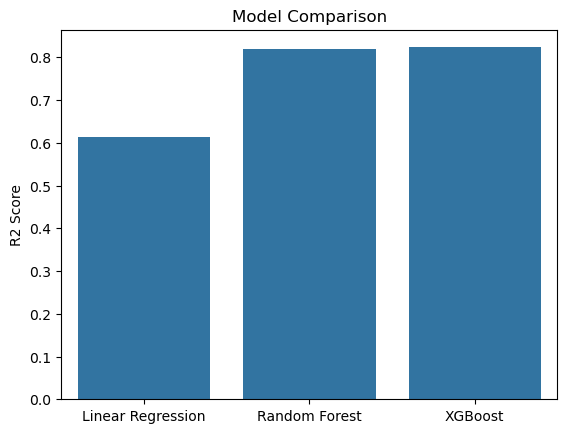

In [27]:
#Model comparison
model_names =['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores =[r2_score(y_test, lr_pred),
            r2_score(y_test, rf_pred),
            r2_score(y_test, y_pred)]

sns.barplot(x=model_names,y=r2_scores)
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()